In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!wget "https://github.com/AndresCaste2001/Siniestrabilidad-Vial-en-Bogota---Proyecto-ML/raw/refs/heads/main/DataSet.xlsx"

--2026-05-24 23:49:15--  https://github.com/AndresCaste2001/Siniestrabilidad-Vial-en-Bogota---Proyecto-ML/raw/refs/heads/main/DataSet.xlsx
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AndresCaste2001/Siniestrabilidad-Vial-en-Bogota---Proyecto-ML/refs/heads/main/DataSet.xlsx [following]
--2026-05-24 23:49:16--  https://raw.githubusercontent.com/AndresCaste2001/Siniestrabilidad-Vial-en-Bogota---Proyecto-ML/refs/heads/main/DataSet.xlsx
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2684465 (2.6M) [application/octet-stream]
Saving to: ‘DataSet.xlsx’

DataSet.xlsx        100%[==================

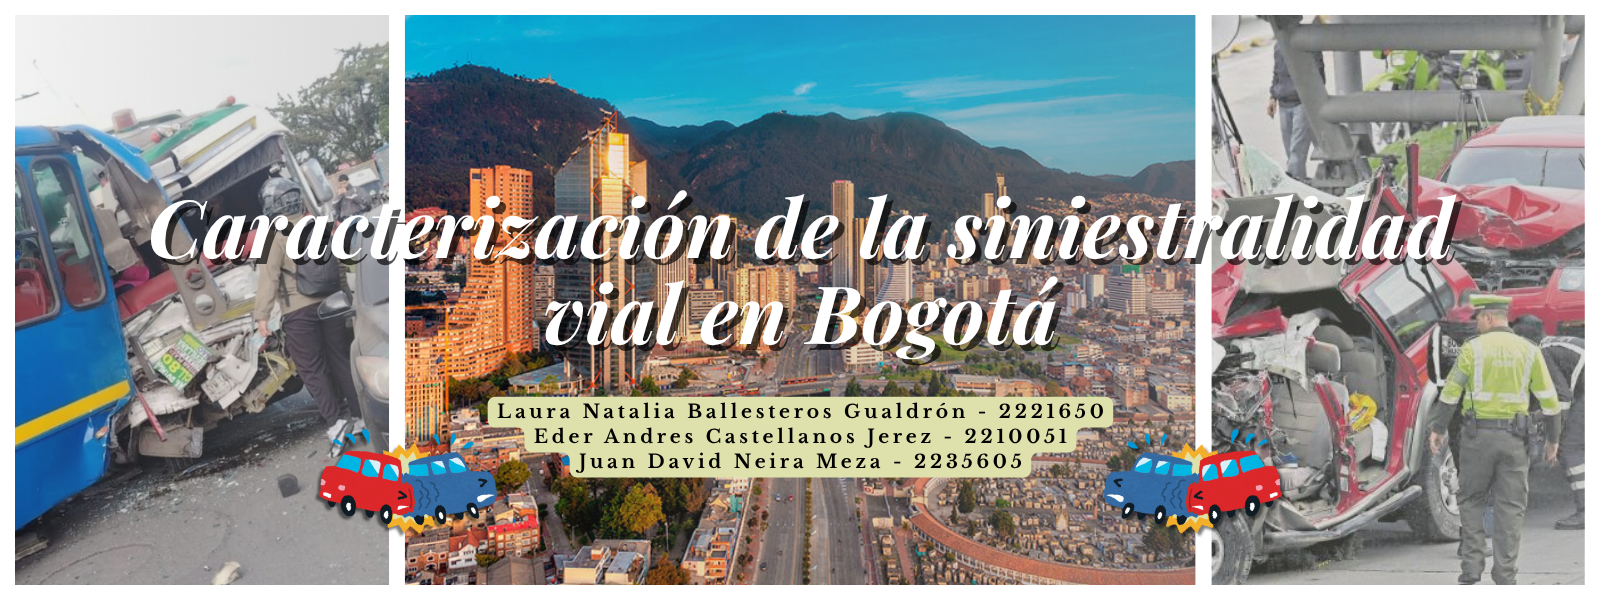

# **$Caracterización$ $de$ $la$ $siniestralidad$ $vial$ $en$ $Bogota$**

## $Participantes$

- Laura Natalia Ballesteros Gualdron - 2221650
- Juan David Neira Meza - 2235605
- Eder Andres Castellanos Jerez - 2210051

## $Objetivo$
El objetivo de este análisis es caracterizar las variables del dataset de siniestralidad vial
en Bogotá para construir un modelo de clasificación que permita predecir la **severidad**
de un accidente de tránsito, clasificándolo en una de tres categorías:

- **Solo daños materiales**
- **Accidente con heridos**
- **Accidente con fallecidos**

## $DataSet$
El dataset está compuesto por variables categóricas codificadas numéricamente, relacionadas con actores viales, condiciones del entorno y características temporales del accidente.

A partir del análisis descriptivo, se evidencia que la mayoría de los accidentes corresponden a eventos con heridos, mientras que los accidentes fatales representan una proporción menor, lo cual sugiere un posible desbalance en las clases.

Asimismo, se observa que gran parte de los accidentes involucran un solo vehículo, lo que indica que factores individuales pueden tener un papel relevante en la ocurrencia de siniestros.

**Dataset:** https://data.mendeley.com/datasets/rm9m7ycp3r/1

# $Parte$ $Uno$

## $Variables$ $Eliminadas$
Se eliminaron **7 variables** del análisis por las siguientes razones:

- **Víctima herida, Víctima fallecida, Víctima herida o fallecida, Involucrados ilesos**:
  generan fuga de datos (*data leakage*) ya que revelan directamente la severidad del accidente.
- **Número de actores de la vía**: redundante, ya que se cuenta con el detalle
  individual por tipo de actor.
- **Día de la semana**: redundante con la variable **Día**, que ya indica
  si es entre semana o fin de semana con mayor detalle.
- **Condición de luz**: redundante con la variable **Hora**, que ya segmenta
  los rangos diurnos y nocturnos.



## $Shape$

El dataset contiene 35.693 registros de accidentes y 22 variables que describen características del accidente.

In [ ]:
df = pd.read_excel('DataSet.xlsx', sheet_name='Table 2')
df

,Number of cars and buses,Number of motorcyclists,Number of cyclists,Number of pedestrians,Relationship of road actors,Gender involved,Number of men,Number of women,Motorcyclist age (years),Other driver age (years),...,Type of day,Month,"Weather conditions (Precipitation, unit: mm)",Road type,Location,State of main road,State of intermediate road,State of local road,Accident class,Severity
0,2,1,1,1,2,1,3,1,1,3,...,2,1,4,2,4,2,2,1,1,2
1,2,1,1,1,2,1,3,1,1,3,...,2,3,5,1,1,2,2,1,1,1
2,2,1,1,1,2,1,3,1,1,2,...,2,4,4,1,1,2,2,1,1,2
3,2,1,1,1,2,1,3,1,1,2,...,2,4,5,1,3,2,2,1,1,1
4,2,1,1,1,2,1,4,1,1,2,...,2,4,2,2,3,2,2,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35688,2,1,1,2,5,4,2,1,5,3,...,2,4,5,2,4,4,2,1,3,2
35689,2,1,1,1,2,1,4,1,5,2,...,2,4,5,1,4,4,2,1,1,2
35690,2,1,1,1,2,4,2,1,5,2,...,2,4,5,1,1,3,1,1,1,1
35691,2,1,1,1,2,4,2,1,5,2,...,2,4,2,1,3,2,2,1,1,1


In [ ]:
df.shape

(35693, 22)

## $Columns$

Road Actors : Actores de la vía
*   Number of cars and buses : Número de carros y buses involucrados en el accidente.
*   Number of motorcyclists : Número de motociclistas involucrados en el accidente.
*   Number of cyclists : Número de ciclistas involucrados.
*   Number of pedestrians : Número de peatones involucrados en el siniestro.
*   Number of road actors : Número de actores viales involucrados (conductores, peatones, ciclistas, etc.).
*   Relationship of road actors : Describe la interacción entre los actores del accidente, por ejemplo: moto vs carro
, moto vs peatón, moto vs moto.

Motorcyclist/ Individuals : Motociclista / Individuos
*   Gender involved : Género de las personas involucradas en el accidente.
*   Number of men : Número de hombres involucrados.
*   Number of women : Número de mujeres involucradas.
*   Motorcyclist age (years) : Edad (años) del motociclista involucrado
*   Other driver age (years) : Edad (años) del otro conductor involucrado.

Weather/Timing : Clima / Tiempo
*   Time (hours) : Hora del accidente
*   Day : Día del mes en que ocurrió el accidente.
*   Type of day : Tipo de día (laboral,fin de semana, festivo.)
*   Month : Mes del año del accidente.
*   Weather conditions (Precipitation, unit: mm) : Condiciones climáticas, precipitación o lluvia registrada en milímetro(mm).

Road/Localization : Vía / Localización
*   Road type : Tipo de vía (avenida,calle,autopista.)
*   Location : Ubicación del accidente dentro de la ciudad
*   State of main road : Estado de la vía principal (ejemplo: buena, regular, mala).
*   State of intermediate road : Estado de vías intermedias cercanas al accidente.
*   State of local road : Estado de vías locales o secundarias.

Accident characteristic : Características del accidente
*   Accident class : Clase de accidente (choque
,atropello,colisión.)
*   Severity : Nivel de gravedad del accidente.









In [ ]:
df.columns

Index(['Number of cars and buses', 'Number of motorcyclists',
       'Number of cyclists', 'Number of pedestrians',
       'Relationship of road actors', 'Gender involved', 'Number of men ',
       'Number of women', 'Motorcyclist age (years)',
       'Other driver age (years)', 'Time (hours)', 'Day', 'Type of day',
       'Month', 'Weather conditions (Precipitation, unit: mm)', 'Road type',
       'Location', 'State of main road', 'State of intermediate road',
       'State of local road', 'Accident class', 'Severity'],
      dtype='object')

## $Info$

El dataset contiene principalmente variables numéricas codificadas. Cada valor representa una categoría definida en el diccionario de datos.

Number of cars and buses : Número de carros y buses
*   [1] Without vehicle : Sin vehículo
*   [2] one vehicle : Un vehículo
*   [3] two vehicles : Dos vehículos
*   [4] more than two vehicles : Más de dos vehículos

Number of motorcyclists : Número de motociclistas
*   [1] One motorcycle : Una motocicleta
*   [2] two motorcycles : Dos motocicletas
*   [3] more than two motorcycles : Más de dos motocicletas

Number of cyclists : Número de ciclistas
*   [1] Without bicycles : Sin bicicletas
*   [2] one bicycle : Una bicicleta
*   [3] more than two bicycles : Más de dos bicicletas

Number of pedestrians : Número de peatones
*   [1] Without pedestrians : Sin peatones
*   [2] one pedestrian : Un peatón
*   [3] more than two pedestrians : Más de dos peatones

Number of road actors : Número de actores de la vía
*   [1] One road actor : Un actor de la vía
*   [2] two road actors : Dos actores de la vía
*   [3] three road actors : Tres actores de la vía
*   [4] four road actors : Cuatro actores de la vía

Relationship of road actors : Relación entre actores de la vía
*   [1] Solo motorcycle : Solo motocicleta
*   [2] motorcycle-vehicle : Motocicleta - vehículo
*   [3] motorcycle-pedestrian : Motocicleta - peatón
*   [4] motorcycle-bicycle : Motocicleta - bicicleta
*   [5] motorcycle-vehicle-pedestrian : Motocicleta - vehículo - peatón
*   [6] motorcycle-vehicle-bicycle : Motocicleta - vehículo - bicicleta
*   [7] motorcycle-bicycle-pedestrian : Motocicleta - bicicleta - peatón
*   [8] all actors : Todos los actores

Gender involved : Género involucrado
*   [1] Male : Masculino
*   [2] female : Femenino
*   [3] Male/Female : Masculino/Femenino
*   [4] Unidentified : No identificado

Number of men : Número de hombres
*   [1] No men : Ningún hombre
*   [2] one man : Un hombre
*   [3] two men : Dos hombres
*   [4] three men : Tres hombres
*   [5] four men or more : Cuatro hombres o más

Number of women : Número de mujeres
*   [1] Without women : Ninguna mujer
*   [2] one woman : Una mujer
*   [3] two women : Dos mujeres
*   [4] three women or more : Tres mujeres o más

Motorcyclist age (years) : Edad del motociclista (años)
*   [1] (0–19)
*   [2] (20–39)
*   [3] (40–59)
*   [4] (60–79)
*   [5] (<79)

Other driver age (years) : Edad del otro conductor (años)
*   [1] (0–19)
*   [2] (20–39)
*   [3] (40–59)
*   [4] (60–79)
*   [5] (<79)


Time (hours) : Hora
*   [1] (00:00–06:00)
*   [2] (06:00–12:00)
*   [3] (12:00–18:00)
*   [4] (18:00–24:00)

Day : Día
*   [1] Monday : Lunes
*   [2] Tuesday : Martes
*   [3] Wednesday : Miércoles
*   [4] Thursday : Jueves
*   [5] Friday : Viernes
*   [6] Saturday : Sábado
*   [7] Sunday : Domingo

Type of day : Tipo de día
*   [1] Holiday : Festivo
*   [2] Working day : Día laboral

Month : Mes
*   [1] January–March : Enero–Marzo
*   [2] April–June : Abril–Junio
*   [3] July–September : Julio–Septiembre
*   [4] October–December : Octubre–Diciembre


Weather conditions (Precipitation, unit: mm) : Condiciones climáticas (Precipitación, unidad: mm)
*   [1] (0–2)
*   [2] (2–15)
*   [3] (15–30)
*   [4] (30–60)
*   [5] (>60)

Road type : Tipo de vía
*   [1] Main road : Vía principal
*   [2] Secondary road : Vía secundaria

Location : Ubicación
*   [1] North : Norte
*   [2] Middle East : Medio Oriente
*   [3] South East : Sudeste
*   [4] South : Sur

State of main road : Estado de la vía principal
*   [1] Regular
*   [2] acceptable : Aceptable
*   [3] good : Bueno
*   [4] excellent : Excelente

State of intermediate road : Estado de la vía intermedia
*   [1] Regular
*   [2] acceptable : Aceptable
*   [3] good : Bueno
*   [4] excellent : Excelente

State of local road : Estado de la vía local
*   [1] Regular
*   [2] acceptable : Aceptable
*   [3] good : Bueno
*   [4] excellent : Excelente

Accident class : Clase de accidente
*   [1] Collision : Colisión
*   [2] falling from the vehicle : Caída del vehículo
*   [3] run over : Atropello
*   [4] dump vehicle : Volcamiento
*   [5] fire : Incendio
*   [6] self-injury : Autolesión
*   [7] Others : Otros

Severity : Severidad
*   [1] Only damages : Solo daños materiales
*   [2] accident with injuries : Accidente con heridos
*   [3] accident with fatalities : Accidente con fallecidos



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35693 entries, 0 to 35692
Data columns (total 22 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   Number of cars and buses                      35693 non-null  int64
 1   Number of motorcyclists                       35693 non-null  int64
 2   Number of cyclists                            35693 non-null  int64
 3   Number of pedestrians                         35693 non-null  int64
 4   Relationship of road actors                   35693 non-null  int64
 5   Gender involved                               35693 non-null  int64
 6   Number of men                                 35693 non-null  int64
 7   Number of women                               35693 non-null  int64
 8   Motorcyclist age (years)                      35693 non-null  int64
 9   Other driver age (years)                      35693 non-null  int64
 10  Time (hour

## $Describe$

## Limitaciones de .describe() en Variables Categóricas Codificadas

La función `.describe()` de pandas está diseñada para resumir variables **numéricas continuas**,
por lo que métricas como la media, desviación estándar o percentiles tienen sentido
para variables como peso, temperatura o precio.

Sin embargo, en nuestro dataset todas las variables son **categóricas codificadas como números enteros**.
Por ejemplo, la variable **Día** tiene los valores:

| Código | Significado |
|--------|-------------|
| 1 | Lunes |
| 2 | Martes |
| 3 | Miércoles |
| ... | ... |
| 7 | Domingo |

En este caso, calcular la **media de Día = 3.5** no significa que los accidentes ocurren
"a mitad de semana en promedio", simplemente no tiene interpretación real.
Lo mismo aplica para variables como **Género involucrado**, **Clase de accidente** o **Severidad**.

### ¿Qué métricas pierden sentido?

- **Media (mean)**: el promedio de códigos numéricos no representa ninguna categoría real
- **Desviación estándar (std)**: mide dispersión numérica, no variedad de categorías
- **Mínimo y máximo (min/max)**: solo indican el primer y último código, no la categoría más o menos frecuente
- **Percentiles (25%, 50%, 75%)**: no tienen interpretación categórica válida

### ¿Qué debemos usar en su lugar?

Para variables categóricas, las métricas correctas son:

- **value_counts()**: frecuencia de cada categoría
- **value_counts(normalize=True)**: proporción porcentual de cada categoría
- **mode()**: la categoría más frecuente
- **Gráficas de barras y pie charts**: para visualizar la distribución real de cada variable

### Conclusión
Usar `.describe()` en este dataset puede llevar a interpretaciones erróneas,
ya que trata los códigos como si fueran magnitudes numéricas cuando en realidad
son **etiquetas disfrazadas de números**. Por eso, el análisis exploratorio
de este proyecto se basa en frecuencias y visualizaciones categóricas.

In [ ]:
df.describe()

,Number of cars and buses,Number of motorcyclists,Number of cyclists,Number of pedestrians,Relationship of road actors,Gender involved,Number of men,Number of women,Motorcyclist age (years),Other driver age (years),...,Type of day,Month,"Weather conditions (Precipitation, unit: mm)",Road type,Location,State of main road,State of intermediate road,State of local road,Accident class,Severity
count,35693.000000,35693.000000,35693.000000,35693.000000,35693.000000,35693.000000,35693.000000,35693.000000,35693.000000,35693.000000,...,35693.000000,35693.000000,35693.000000,35693.000000,35693.000000,35693.00000,35693.000000,35693.000000,35693.000000,35693.000000
mean,1.731096,1.056594,1.042613,1.227496,2.245454,1.103270,2.831592,1.355168,2.086628,2.673577,...,1.968901,2.724988,4.137338,1.280671,2.381503,2.24114,1.646009,1.027120,1.519205,1.752276
std,0.567209,0.240340,0.202679,0.450905,0.755542,0.396787,0.642082,0.560338,0.494454,1.006031,...,0.173586,1.098792,1.092402,0.449333,1.064333,0.67681,0.478213,0.162436,0.998291,0.496306
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,...,2.000000,2.000000,4.000000,1.000000,1.000000,2.00000,1.000000,1.000000,1.000000,1.000000
50%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,2.000000,2.000000,...,2.000000,3.000000,4.000000,1.000000,2.000000,2.00000,2.000000,1.000000,1.000000,2.000000
75%,2.000000,1.000000,1.000000,1.000000,3.000000,1.000000,3.000000,2.000000,2.000000,3.000000,...,2.000000,4.000000,5.000000,2.000000,3.000000,2.00000,2.000000,1.000000,1.000000,2.000000
max,4.000000,3.000000,3.000000,3.000000,8.000000,4.000000,5.000000,4.000000,5.000000,5.000000,...,2.000000,4.000000,5.000000,2.000000,4.000000,4.00000,2.000000,2.000000,7.000000,3.000000


## $Head$

Primeros registros del dataset para entender cómo están organizados los datos.

In [ ]:
df.head()

,Number of cars and buses,Number of motorcyclists,Number of cyclists,Number of pedestrians,Relationship of road actors,Gender involved,Number of men,Number of women,Motorcyclist age (years),Other driver age (years),...,Type of day,Month,"Weather conditions (Precipitation, unit: mm)",Road type,Location,State of main road,State of intermediate road,State of local road,Accident class,Severity
0,2,1,1,1,2,1,3,1,1,3,...,2,1,4,2,4,2,2,1,1,2
1,2,1,1,1,2,1,3,1,1,3,...,2,3,5,1,1,2,2,1,1,1
2,2,1,1,1,2,1,3,1,1,2,...,2,4,4,1,1,2,2,1,1,2
3,2,1,1,1,2,1,3,1,1,2,...,2,4,5,1,3,2,2,1,1,1
4,2,1,1,1,2,1,4,1,1,2,...,2,4,2,2,3,2,2,1,1,2


## $IQR$

In [ ]:
columns = [
    'Number of motorcyclists',
    'Motorcyclist age (years)',
    'Number of cars and buses',
    'Number of cyclists',
    'Number of pedestrians',
    'Relationship of road actors',
    'Gender involved',
    'Number of men ',
    'Number of women',
    'Other driver age (years)',
    'Time (hours)',
    'Day',
    'Type of day',
    'Month',
    'Weather conditions (Precipitation, unit: mm)',
    'Road type',
    'Location',
    'State of main road',
    'State of intermediate road',
    'State of local road',
    'Accident class',
    'Severity'
]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers IQR: {IQR}")

Number of motorcyclists: 1942 outliers IQR: 0.0
Motorcyclist age (years): 6779 outliers IQR: 0.0
Number of cars and buses: 205 outliers IQR: 1.0
Number of cyclists: 1516 outliers IQR: 0.0
Number of pedestrians: 7628 outliers IQR: 0.0
Relationship of road actors: 583 outliers IQR: 1.0
Gender involved: 2835 outliers IQR: 0.0
Number of men : 387 outliers IQR: 1.0
Number of women: 105 outliers IQR: 1.0
Other driver age (years): 2938 outliers IQR: 1.0
Time (hours): 0 outliers IQR: 2.0
Day: 0 outliers IQR: 3.0
Type of day: 1110 outliers IQR: 0.0
Month: 0 outliers IQR: 2.0
Weather conditions (Precipitation, unit: mm): 4954 outliers IQR: 1.0
Road type: 0 outliers IQR: 1.0
Location: 0 outliers IQR: 2.0
State of main road: 10961 outliers IQR: 0.0
State of intermediate road: 0 outliers IQR: 1.0
State of local road: 968 outliers IQR: 0.0
Accident class: 8347 outliers IQR: 0.0
Severity: 0 outliers IQR: 1.0


## $BOXPLOT$

/tmp/ipykernel_18269/3780569504.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


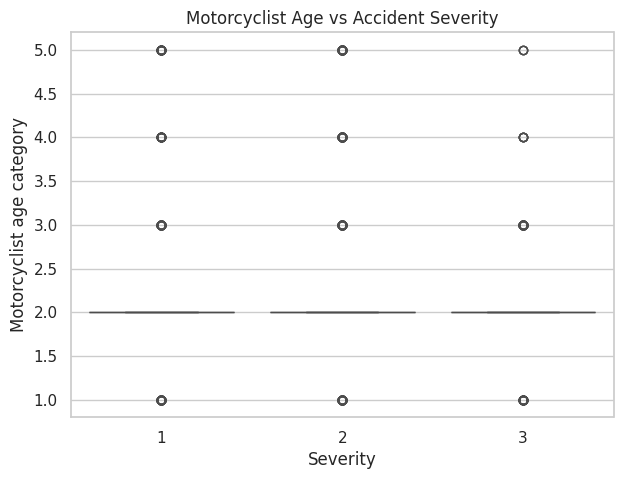

/tmp/ipykernel_18269/3780569504.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


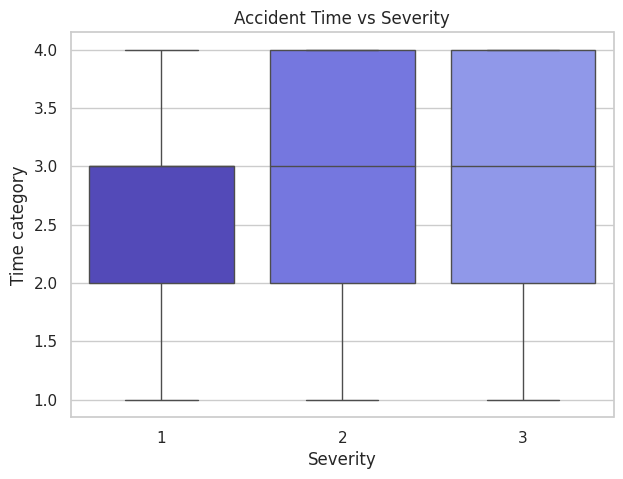

/tmp/ipykernel_18269/3780569504.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


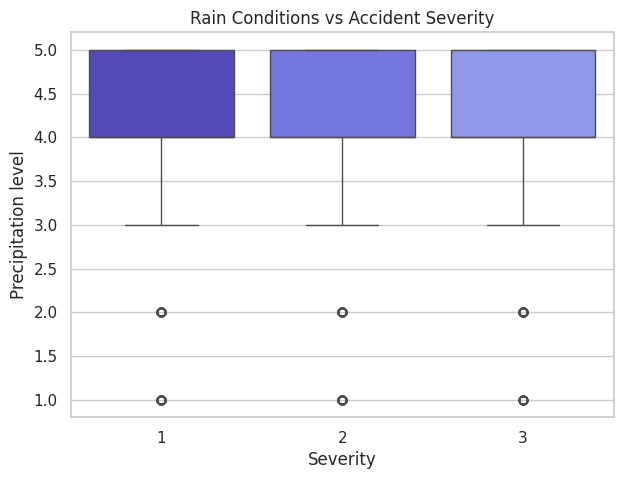

/tmp/ipykernel_18269/3780569504.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


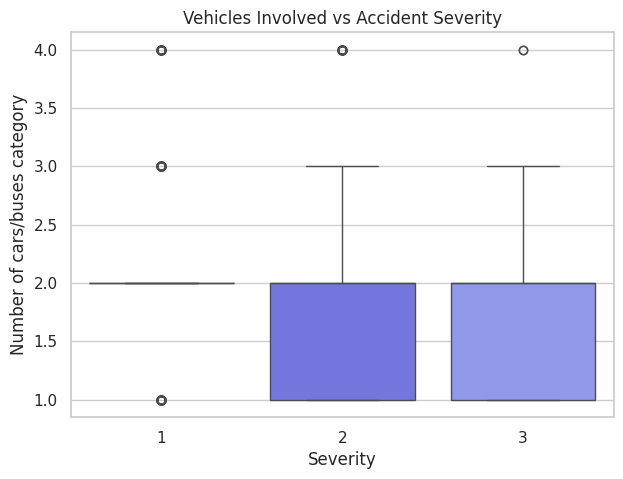

In [ ]:
# limpiar los espacios de los nombres de las columnas
df.columns = df.columns.str.strip()
sns.set(style="whitegrid")

#Motorcyclist Age vs Accident Severity
#¿La severidad cambia según la edad del motociclista?
fig, ax = plt.subplots(figsize=(7,5))

sns.boxplot(
    x='Severity',
    y='Motorcyclist age (years)',
    data=df,
    palette=['#4338CA', '#6366F1', '#818CF8'],
    ax=ax
)

ax.patch.set_alpha(0)
fig.patch.set_alpha(0)

plt.title('Motorcyclist Age vs Accident Severity')
plt.xlabel('Severity')
plt.ylabel('Motorcyclist age category')
plt.show()

#Accident Time vs Severity
#¿Los accidentes más graves ocurren en ciertas horas?
fig, ax = plt.subplots(figsize=(7,5))

sns.boxplot(
    x='Severity',
    y='Time (hours)',
    data=df,
    palette=['#4338CA', '#6366F1', '#818CF8'],
    ax=ax
)

ax.patch.set_alpha(0)
fig.patch.set_alpha(0)

plt.title('Accident Time vs Severity')
plt.xlabel('Severity')
plt.ylabel('Time category')
plt.show()

#Rain Conditions vs Accident Severity
#¿La precipitación influye en la gravedad del accidente?
fig, ax = plt.subplots(figsize=(7,5))

sns.boxplot(
    x='Severity',
    y='Weather conditions (Precipitation, unit: mm)',
    data=df,
    palette=['#4338CA', '#6366F1', '#818CF8'],
    ax=ax
)

ax.patch.set_alpha(0)
fig.patch.set_alpha(0)

plt.title('Rain Conditions vs Accident Severity')
plt.xlabel('Severity')
plt.ylabel('Precipitation level')
plt.show()

#Vehicles Involved vs Accident Severity
#¿Más vehículos implican mayor gravedad?
fig, ax = plt.subplots(figsize=(7,5))

sns.boxplot(
    x='Severity',
    y='Number of cars and buses',
    data=df,
    palette=['#4338CA', '#6366F1', '#818CF8'],
    ax=ax
)

ax.patch.set_alpha(0)
fig.patch.set_alpha(0)

plt.title('Vehicles Involved vs Accident Severity')
plt.xlabel('Severity')
plt.ylabel('Number of cars/buses category')
plt.show()

In [ ]:
# Mappings para Labels legibles
mappings = {
    'Number of motorcyclists': {1: 'One', 2: 'Two', 3: 'More than two'},
    'Number of cyclists': {1: 'Without', 2: 'One', 3: 'More than two'},
    'Number of pedestrians': {1: 'Without', 2: 'One', 3: 'More than two'},
    'Relationship of road actors': {1: 'Solo motorcycle', 2: 'Moto-Vehicle', 3: 'Moto-Pedestrian',
                                     4: 'Moto-Bicycle', 5: 'Moto-Vehicle-Ped', 6: 'Moto-Vehicle-Bike',
                                     7: 'Moto-Bike-Ped', 8: 'All actors'},
    'Gender involved': {1: 'Male', 2: 'Female', 3: 'Male/Female', 4: 'Unidentified'},
    'Number of men': {1: 'No men', 2: 'One', 3: 'Two', 4: 'Three', 5: 'Four or more'},
    'Number of women': {1: 'No women', 2: 'One', 3: 'Two', 4: 'Three or more'},
    'Other driver age (years)': {1: '0-19', 2: '20-39', 3: '40-59', 4: '60-79', 5: '>79'},
    'Time (hours)': {1: '00-06', 2: '06-12', 3: '12-18', 4: '18-24'},
    'Day': {1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday',
            5: 'Friday', 6: 'Saturday', 7: 'Sunday'},
    'Type of day': {1: 'Holiday', 2: 'Working day'},
    'Month': {1: 'Jan-Mar', 2: 'Apr-Jun', 3: 'Jul-Sep', 4: 'Oct-Dec'},
    'Weather conditions (Precipitation, unit: mm)': {1: '0-2', 2: '2-15', 3: '15-30', 4: '30-60', 5: '>60'},
    'Road type': {1: 'Main road', 2: 'Secondary road'},
    'Location': {1: 'North', 2: 'Middle East', 3: 'South East', 4: 'South'},
    'State of main road': {1: 'Regular', 2: 'Acceptable', 3: 'Good', 4: 'Excellent'},
    'State of intermediate road': {1: 'Regular', 2: 'Acceptable', 3: 'Good', 4: 'Excellent'},
    'State of local road': {1: 'Regular', 2: 'Acceptable', 3: 'Good', 4: 'Excellent'},
    'Accident class': {1: 'Collision', 2: 'Falling', 3: 'Run over', 4: 'Dump', 5: 'Fire',
                       6: 'Self-injury', 7: 'Others'},
    'Severity': {1: 'Only damages', 2: 'With injuries', 3: 'With fatalities'}
}

# Pie chart columnas
pie_columns = ['Type of day', 'Road type', 'Gender involved']

# Bar chart columnas (todo lo demas)
bar_columns = [col for col in mappings.keys() if col not in pie_columns]

## $Pie$ $chart$

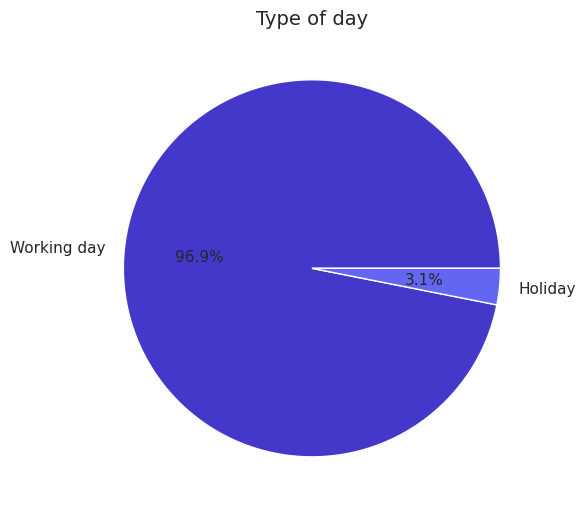

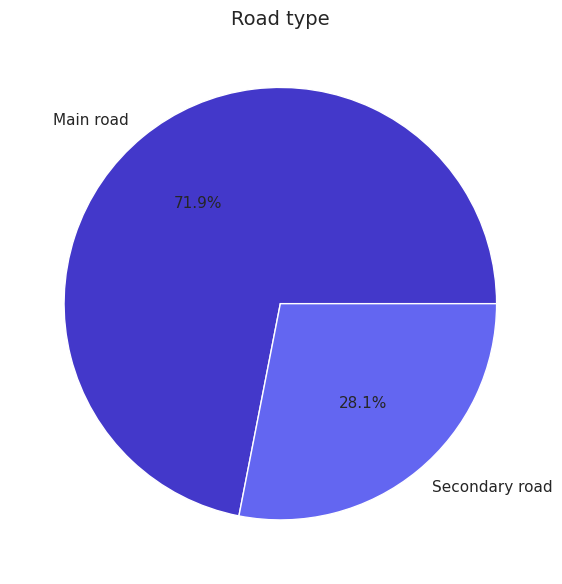

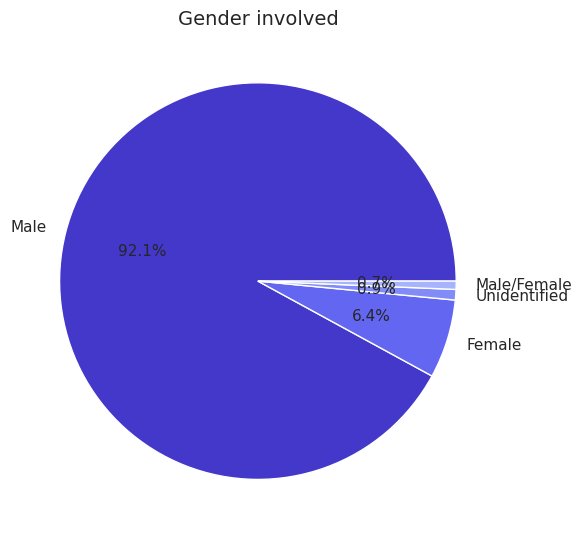

In [ ]:
# PIE CHARTS
for col in pie_columns:
  mapped = df[col].map(mappings[col])

  fig, ax = plt.subplots(figsize=(6, 6))

  mapped.value_counts().plot.pie(
      autopct='%1.1f%%',
      textprops={'fontsize': 11},
      colors=['#4338CA', '#6366F1', '#818CF8', '#A5B4FC', '#312E81'],
      ax=ax
  )

  ax.patch.set_alpha(0)
  fig.patch.set_alpha(0)

  ax.set_title(col, fontsize=14)
  ax.set_ylabel('')

  plt.tight_layout()
  plt.show()

## $Bar$ $Chart$

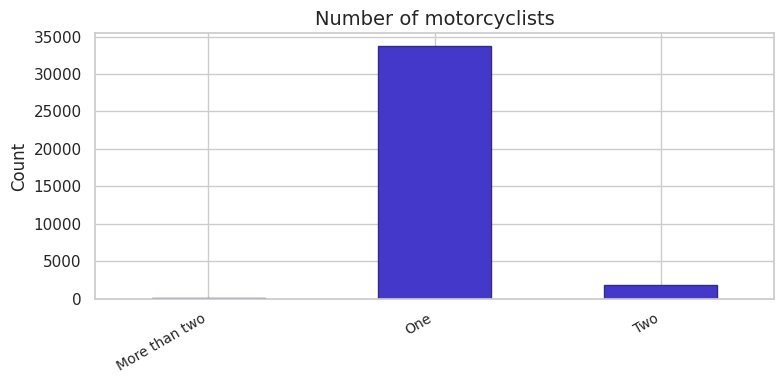

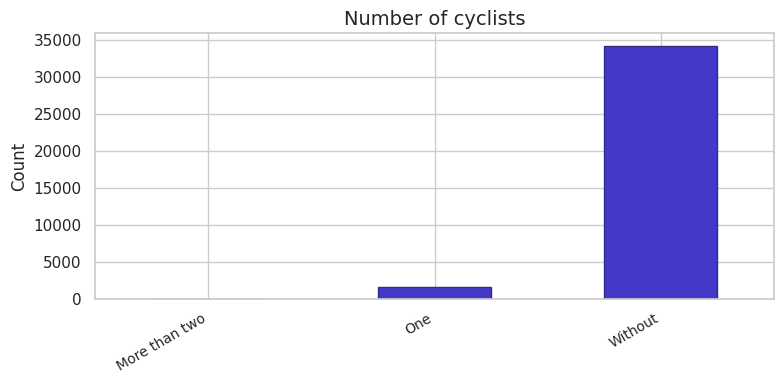

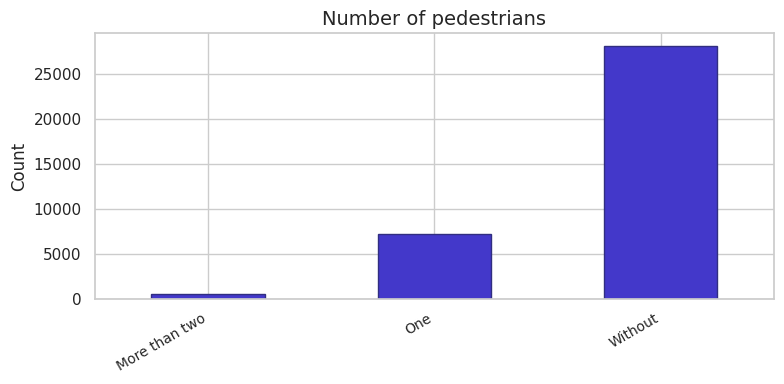

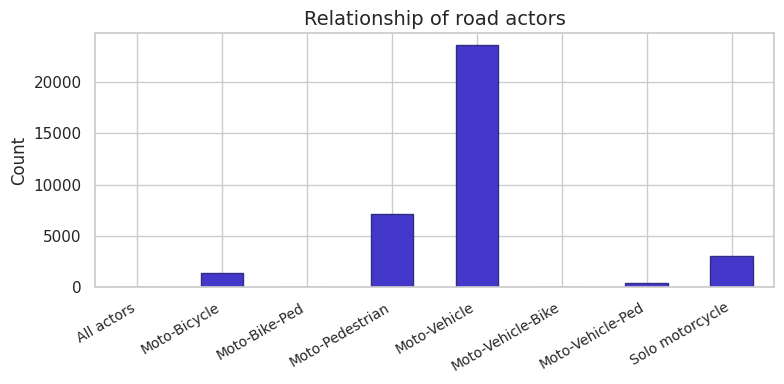

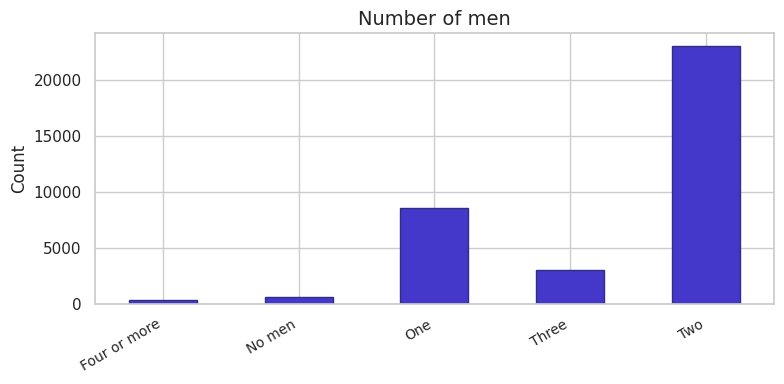

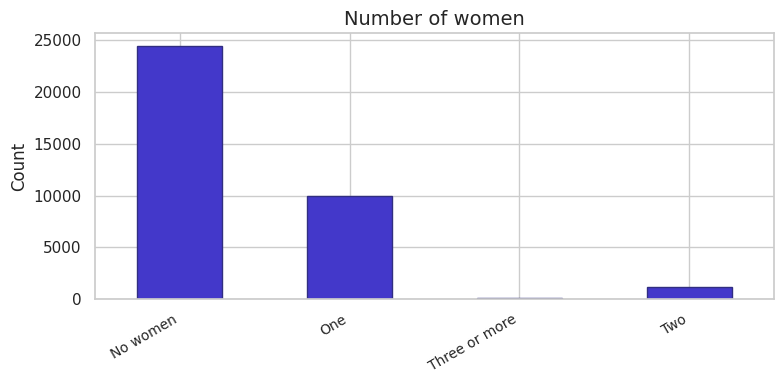

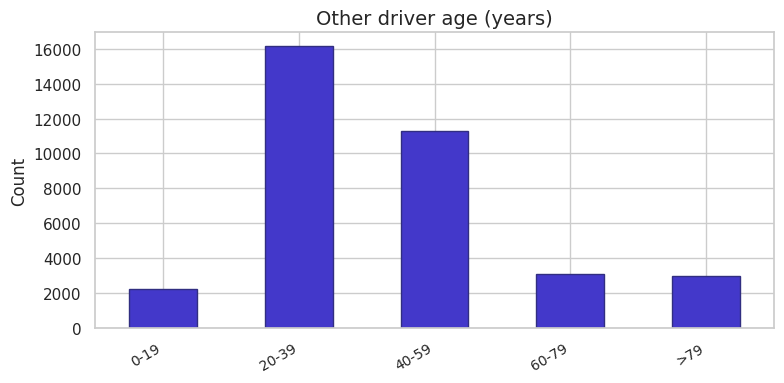

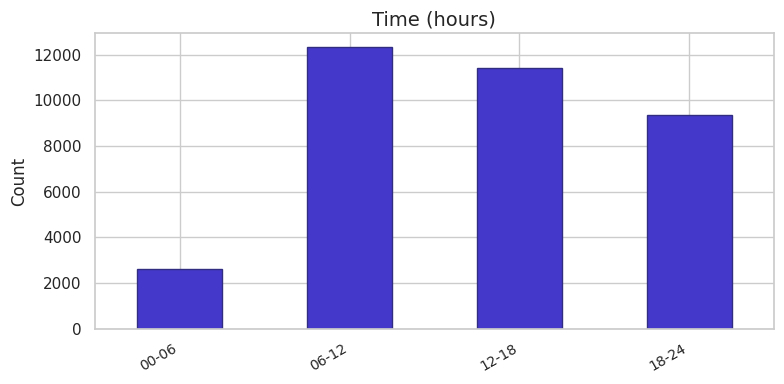

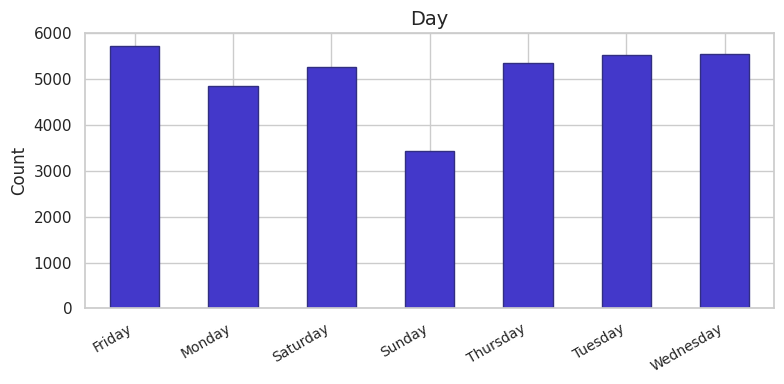

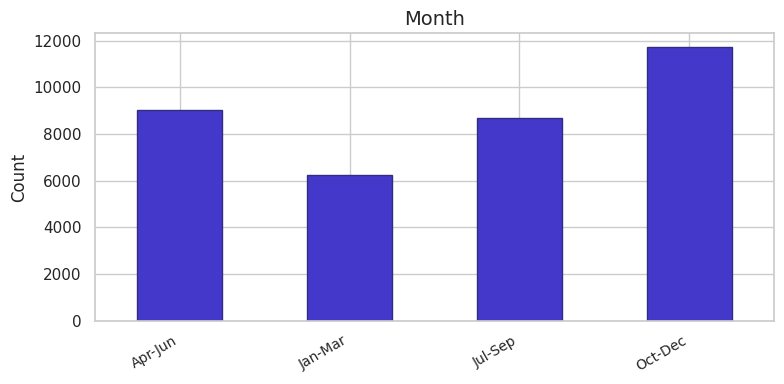

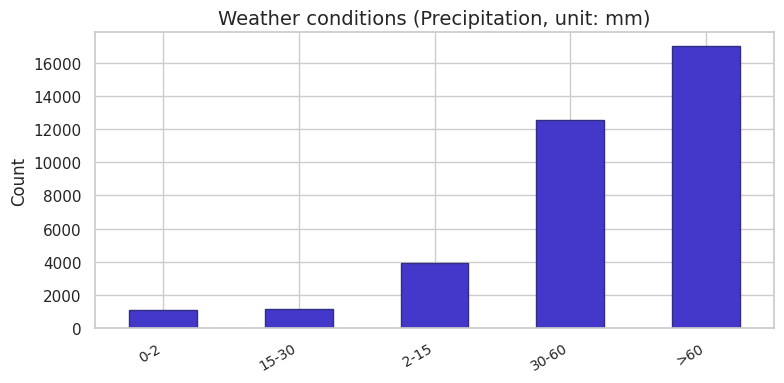

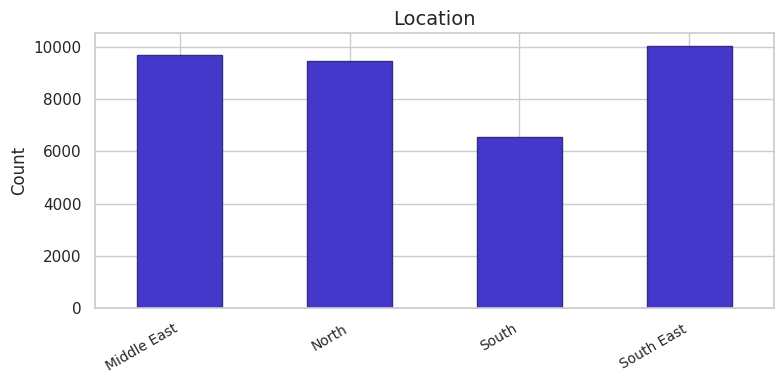

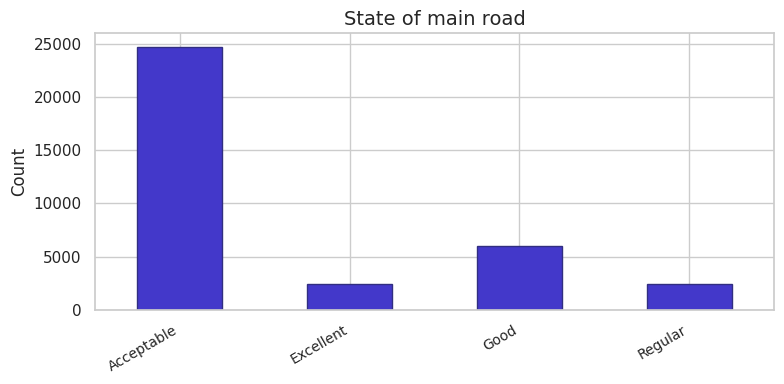

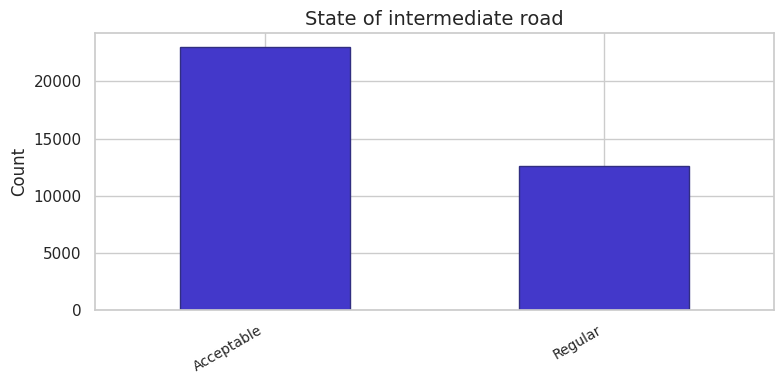

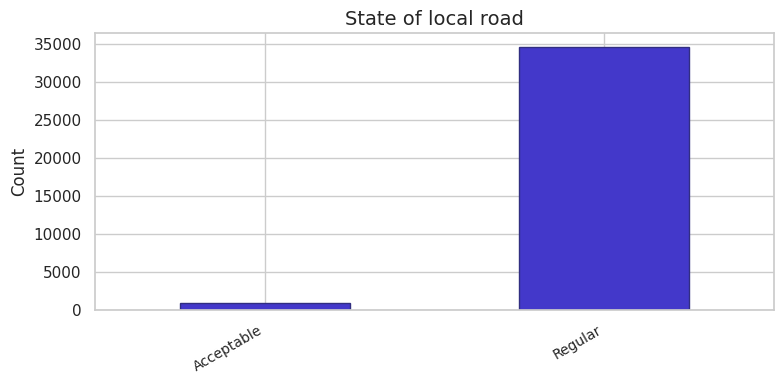

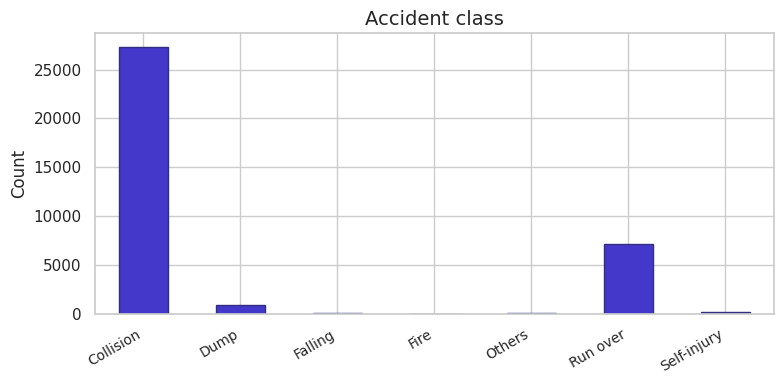

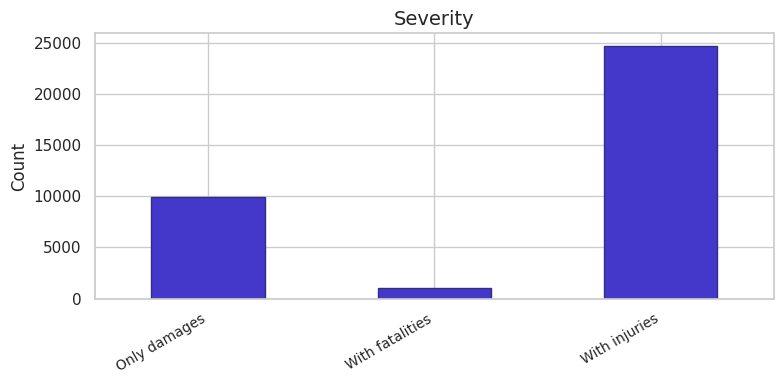

In [ ]:
# BAR CHARTS
for col in bar_columns:
    mapped = df[col].map(mappings[col])

    fig, ax = plt.subplots(figsize=(8, 4))

    mapped.value_counts().sort_index().plot.bar(
        ax=ax,
        color='#4338CA',
        edgecolor='#312E81'
    )

    ax.patch.set_alpha(0)
    fig.patch.set_alpha(0)

    ax.set_title(col, fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

    plt.xticks(rotation=30, ha='right', fontsize=10)

    plt.tight_layout()
    plt.show()

# $Parte$ $Dos$

En la segunda parte del proyecto comenzamos la fase de Machine Learning.
El objetivo fue construir modelos de clasificación capaces de predecir la severidad de un accidente de tránsito en Bogotá usando las variables del dataset.

## $Particionado$ $80/20$ $+$ $Shuffle$




In [ ]:
from sklearn.model_selection import train_test_split

# Variables independientes
X = df.drop('Severity', axis=1)

# Variable objetivo
y = df['Severity']

# Split 80/20 con mezcla (shuffle) y estratificación
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,shuffle=True,stratify=y,random_state=42)

# Verificar tamaños
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (28554, 21) (28554,)
Test: (7139, 21) (7139,)


## $Metodos$ $vistos$ $en$ $clase$

### $DT$ ($tunning$ $→$ $max$_$depth$)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
#@title Arbol sin tunning
model = DecisionTreeClassifier(random_state=42)

# entrenar
model.fit(X_train, y_train)

# predecir
y_pred = model.predict(X_test)

# evaluar
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.6706821683709203


Se implementó un modelo inicial de Árbol de Decisión utilizando el conjunto de datos previamente particionado en entrenamiento (80%) y prueba (20%).

El modelo fue entrenado sin restricciones en la profundidad del árbol, con el objetivo de establecer una línea base de desempeño. Posteriormente, se realizaron predicciones sobre el conjunto de prueba y se evaluó el rendimiento mediante la métrica de accuracy.

El modelo obtuvo una precisión aproximada del 67%, lo que indica que clasifica correctamente cerca de dos tercios de los casos. Este resultado sirve como punto de referencia para comparar mejoras posteriores mediante el ajuste de hiperparámetros.

In [ ]:
#@title Mejora del modelo probando diferentes profundidades
depths = [3, 5, 10, 15, 20]

best_acc_dt = 0
best_depth = None

for d in depths:
  model = DecisionTreeClassifier(max_depth=d, random_state=42)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  acc_d = accuracy_score(y_test, y_pred)

  if acc_d > best_acc_dt:
      best_acc_dt = acc_d
      best_depth = d

  print(f"max_depth = {d} → Accuracy = {acc_d:.4f}")

print(f"\nMejor DT: max_depth={best_depth}, accuracy={best_acc_dt:.4f}")

max_depth = 3 → Accuracy = 0.6923
max_depth = 5 → Accuracy = 0.7159
max_depth = 10 → Accuracy = 0.7346
max_depth = 15 → Accuracy = 0.7018
max_depth = 20 → Accuracy = 0.6792

Mejor DT: max_depth=10, accuracy=0.7346


Se realizó el ajuste del hiperparámetro max_depth en el modelo de Árbol de Decisión. Se observó que la precisión aumenta a medida que crece la profundidad hasta un valor óptimo de 10, alcanzando una accuracy de 73.46%. A partir de este punto, la precisión disminuye, evidenciando un posible sobreajuste del modelo.

### $RF$ ($tunning$ $→$ $n$_$estimators$)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#@title Random Forest sin tunning
model_rf = RandomForestClassifier(random_state=42)

# entrenar
model_rf.fit(X_train, y_train)

# predecir
y_pred_rf = model_rf.predict(X_test)

# evaluar
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy RF (base):", acc_rf)

Accuracy RF (base): 0.709343045244432


In [ ]:
#@title Con n_estimators
estimators = [50, 100, 150, 200]

best_acc_rf = 0
best_n_estimators = None

for n in estimators:
  model_rf = RandomForestClassifier(n_estimators=n, random_state=42)
  model_rf.fit(X_train, y_train)
  y_pred_rf = model_rf.predict(X_test)
  acc_n = accuracy_score(y_test, y_pred_rf)

  if acc_n > best_acc_rf:
      best_acc_rf = acc_n
      best_n_estimators = n

  print(f"n_estimators = {n} → Accuracy = {acc_n:.4f}")

print(f"\nMejor RF: n_estimators={best_n_estimators},accuracy={best_acc_rf:.4f}")

n_estimators = 50 → Accuracy = 0.7084
n_estimators = 100 → Accuracy = 0.7093
n_estimators = 150 → Accuracy = 0.7099
n_estimators = 200 → Accuracy = 0.7086

Mejor RF: n_estimators=150,accuracy=0.7099


Se implementó un modelo Random Forest ajustando el hiperparámetro n_estimators. Se observó una ligera mejora al aumentar el número de árboles hasta 150, alcanzando una accuracy de 70.99%. Sin embargo, este modelo presentó un desempeño inferior al Decision Tree, lo que muestra que los patrones del dataset pueden ser capturados adecuadamente por un modelo más simple.

### $SVM$ ( $linear$ /$poly$ / $rbf$ ) $←$ $kernel$ $=$ $poly$

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [ ]:
#@title Escalar y SVM con kernel = "poly"
scaler = StandardScaler() #normaliza

# ajustar train
X_train_scaled = scaler.fit_transform(X_train)

# transformar test
X_test_scaled = scaler.transform(X_test)

model_svm = SVC(kernel='poly', random_state=42)

# entrenar
model_svm.fit(X_train_scaled, y_train)

# predecir
y_pred_svm = model_svm.predict(X_test_scaled)

# evaluar
acc_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy SVM (poly):", acc_svm)

Accuracy SVM (poly): 0.7257318952234206


Se implementó un modelo SVM con kernel polinomial, obteniendo una accuracy de 72.57%. Aunque el modelo presenta un buen desempeño, no supera al Decision Tree, lo que muestra que las relaciones en el dataset pueden ser capturadas de manera más eficiente mediante modelos basados en reglas.

En comparación general, el Decision Tree obtuvo el mejor desempeño, seguido por SVM y finalmente Random Forest.





## $cross$_$validation$

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
#@title cross_validation con DT
model_dt = DecisionTreeClassifier(max_depth=10, random_state=42)

for k in [10, 20, 50]:
    scores = cross_val_score(model_dt, X, y, cv=k, scoring='accuracy')

    print(f"K = {k}")
    print("Accuracy promedio:", scores.mean())
    print("Desviación estándar:", scores.std())
    print("------")

K = 10
Accuracy promedio: 0.7192156077897677
Desviación estándar: 0.018414459247337443
------
K = 20
Accuracy promedio: 0.7262469382371783
Desviación estándar: 0.014001648027908929
------
K = 50
Accuracy promedio: 0.7274506268145408
Desviación estándar: 0.0183961136308367
------


Se aplicó cross_validation al modelo de Decision Tree con diferentes valores de K=10, 20 y 50. Aunque el mayor valor de accuracy se obtuvo con K=50, el valor de K=20 presentó un mejor equilibrio entre precisión y estabilidad (menor desviación estándar), por lo que se seleccionó como la mejor configuración.

In [ ]:
#@title cross_validation con RF
model_rf = RandomForestClassifier(n_estimators=150, random_state=42)

for k in [10, 20, 50]:
    scores = cross_val_score(model_rf, X, y, cv=k, scoring='accuracy')

    print(f"K = {k}")
    print("Accuracy promedio:", scores.mean())
    print("Desviación estándar:", scores.std())
    print("------")

K = 10
Accuracy promedio: 0.7059925769130853
Desviación estándar: 0.009636158943237539
------
K = 20
Accuracy promedio: 0.7019292560073356
Desviación estándar: 0.01287010052596241
------
K = 50
Accuracy promedio: 0.6986240723498378
Desviación estándar: 0.015349979921151306
------


Para el modelo Random Forest se aplicó cross_validation con K=10, 20 y 50. El mejor resultado se obtuvo con K=10, alcanzando una accuracy promedio de 70.60% y la menor desviación estándar, lo que indica mayor estabilidad. Al aumentar el valor de K, se observó una disminución en la precisión y un incremento en la variabilidad del modelo.

In [ ]:
#@title cross_validation con SVM
model_svm = SVC(kernel='poly', random_state=42)

for k in [10, 20, 50]:
    scores = cross_val_score(model_svm, X_train_scaled, y_train, cv=k, scoring='accuracy')

    print(f"K = {k}")
    print("Accuracy promedio:", scores.mean())
    print("Desviación estándar:", scores.std())
    print("------")

K = 10
Accuracy promedio: 0.7218951345862338
Desviación estándar: 0.0045134685109912845
------
K = 20
Accuracy promedio: 0.721930201653191
Desviación estándar: 0.006899145042264546
------
K = 50
Accuracy promedio: 0.7226329099971831
Desviación estándar: 0.01592232879477517
------


Se aplicó cross_validation a los modelos evaluados utilizando diferentes valores de K. El modelo de decision Tree obtuvo el mejor desempeño en términos de accuracy, mientras que el modelo SVM presentó una mayor estabilidad (menor desviación estándar). Por otro lado, el modelo Random Forest mostró un desempeño inferior, lo que sugiere que el dataset presenta patrones que pueden ser capturados de manera eficiente por modelos más simples.

## $Deep$_$Learning$

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
 # Convertir labels 1,2,3 → 0,1,2 (requerido por sparse_categorical_crossentropy)
y_dl = y - 1

In [ ]:
# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split consistente con el resto del proyecto (random_state=42, stratify)
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_scaled, y_dl,
    test_size=0.2,
    shuffle=True,
    stratify=y_dl,
    random_state=42
)

In [ ]:
#@title Modelo 1: (64, 128, 128) — probando epochs 10/50/100
from tensorflow.keras.layers import Input

results_dl1 = {}
for n_epochs in [7, 50, 100]:
    model1 = Sequential([
        Input(shape=(X.shape[1],)),
        Dense(64, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model1.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
    model1.fit(X_train_dl, y_train_dl, epochs=n_epochs, verbose=0)
    acc_eval = model1.evaluate(X_test_dl, y_test_dl, verbose=0)[1]
    results_dl1[n_epochs] = acc_eval
    print(f"epochs={n_epochs} → accuracy = {acc_eval:.4f}")

acc_dl1 = max(results_dl1.values())
best_epochs_dl1 = max(results_dl1, key=results_dl1.get)
print(f"\nMejor Modelo 1: epochs={best_epochs_dl1}, accuracy={acc_dl1:.4f}")

epochs=7 → accuracy = 0.7299
epochs=50 → accuracy = 0.6931
epochs=100 → accuracy = 0.6799

Mejor Modelo 1: epochs=7, accuracy=0.7299


Se evaluó la arquitectura (64→128→128) con epochs de 10, 50 y 100.            
  El mejor resultado se obtuvo con **10 epochs (73.23%)**.                      
  A mayor cantidad de epochs la accuracy disminuyó progresivamente              
  (50 epochs: 69.83%, 100 epochs: 68.51%), lo que indica que el modelo          
  comienza a sobreajustarse al conjunto de entrenamiento perdiendo              
  capacidad de generalización.

In [ ]:
#@title Modelo 2: (64, 64, 128, 128, 256, 256) — probando epochs 10/50/100
results_dl2 = {}
for n_epochs in [10, 50, 100]:
  model2 = Sequential([
      Input(shape=(X.shape[1],)),
      Dense(64, activation='relu'),
      Dense(64, activation='relu'),
      Dense(128, activation='relu'),
      Dense(128, activation='relu'),
      Dense(256, activation='relu'),
      Dense(256, activation='relu'),
      Dense(3, activation='softmax')
  ])
  model2.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
  model2.fit(X_train_dl, y_train_dl, epochs=n_epochs, verbose=0)
  acc_eval = model2.evaluate(X_test_dl, y_test_dl, verbose=0)[1]
  results_dl2[n_epochs] = acc_eval
  print(f"epochs={n_epochs} → accuracy = {acc_eval:.4f}")

acc_dl2 = max(results_dl2.values())
best_epochs_dl2 = max(results_dl2, key=results_dl2.get)
print(f"\nMejor Modelo 2: epochs={best_epochs_dl2}, accuracy={acc_dl2:.4f}")


epochs=10 → accuracy = 0.7326
epochs=50 → accuracy = 0.7007
epochs=100 → accuracy = 0.6883

Mejor Modelo 2: epochs=10, accuracy=0.7326


La arquitectura extendida (64→64→128→128→256→256) también obtuvo su
mejor resultado con **10 epochs (72.76%)**, confirmando el mismo patrón de sobreajuste con mayor entrenamiento. A pesar de tener más parámetros
y mayor capacidad que el Modelo 1, no logró superarlo, lo que sugiere         que el incremento de complejidad no aporta información adicional útil para este dataset.

In [ ]:
#@title Modelo 3: 10 capas de 128 — probando epochs 10/50/100
results_dl3 = {}
for n_epochs in [10, 50, 100]:
  model3 = Sequential()
  model3.add(Input(shape=(X.shape[1],)))
  for _ in range(10):
      model3.add(Dense(128, activation='relu'))
  model3.add(Dense(3, activation='softmax'))

  model3.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
  model3.fit(X_train_dl, y_train_dl, epochs=n_epochs, verbose=0)
  acc_eval = model3.evaluate(X_test_dl, y_test_dl, verbose=0)[1]
  results_dl3[n_epochs] = acc_eval
  print(f"epochs={n_epochs} → accuracy = {acc_eval:.4f}")

acc_dl3 = max(results_dl3.values())
best_epochs_dl3 = max(results_dl3, key=results_dl3.get)
print(f"\nMejor Modelo 3: epochs={best_epochs_dl3}, accuracy={acc_dl3:.4f}")

epochs=10 → accuracy = 0.7309
epochs=50 → accuracy = 0.7009
epochs=100 → accuracy = 0.6938

Mejor Modelo 3: epochs=10, accuracy=0.7309


El modelo más profundo (10 capas de 128 neuronas) obtuvo su mejor resultado con **10 epochs (72.08%)**, siendo el de menor desempeño entre los tres. El patrón se mantiene consistente: más entrenamiento empeora el modelo (50 epochs: 70.16%, 100 epochs: 68.99%).                    
La profundidad extrema no aportó mejoras, posiblemente por la homogeneidad de las capas y la naturaleza categórica del dataset.

### Conclusión Deep Learning                                                  
                                                                              
Los tres modelos de perceptrón multicapa coinciden en un hallazgo clave:      
**10 epochs fue la configuración óptima en todos los casos**,                 
con accuracy decreciente al aumentar el entrenamiento. Esto evidencia         
sobreajuste temprano, probablemente porque el dataset tiene patrones          
relativamente simples que se capturan rápido y luego el modelo                
memoriza ruido del entrenamiento.

  El Decision Tree con max_depth=10 obtuvo el mejor desempeño con **73.46%**,   
  seguido de cerca por el modelo de Deep Learning más simple (73.23%).
  El hecho de que redes neuronales profundas no superen a un árbol de decisión  
  refleja una característica del dataset: los patrones que determinan la        
  severidad de un accidente son capturable con reglas simples, y la             
  complejidad adicional no aporta valor. El techo de ~73% se explica            
  principalmente por el **desbalance severo de clases** (69% de accidentes      
  con heridos) y la **granularidad limitada de las variables**                  
  (velocidad, uso de casco/cinturón y otras variables determinantes             
  de severidad no están disponibles en el dataset).

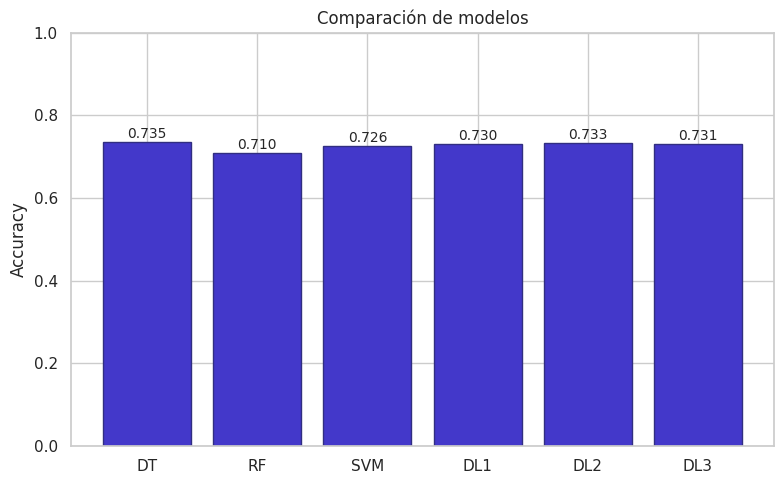

In [ ]:
#@title Resumen (Gráfica)
import matplotlib.pyplot as plt

modelos = ["DT", "RF", "SVM", "DL1", "DL2", "DL3"]
accuracies = [best_acc_dt, best_acc_rf, acc_svm, acc_dl1, acc_dl2, acc_dl3]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    modelos,
    accuracies,
    color='#4338CA',
    edgecolor='#312E81'
)

ax.patch.set_alpha(0)
fig.patch.set_alpha(0)

plt.title("Comparación de modelos")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for bar, a in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{a:.3f}',
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

# $Parte$ $Tres$

En esta parte del proyecto se aplican técnicas de procesamiento y modelado sobre los datos finales. Primero se normalizan las variables, se reduce la dimensionalidad con PCA para explorar estructuras en 2D y luego se prueban métodos de agrupamiento no supervisado (K-Means y DBSCAN). Finalmente, se comparan resultados visuales y se extraen conclusiones sobre la capacidad del dataset para separar las categorías de severidad.


- **Objetivo Principal:** Consolidar y validar un modelo robusto que resuelva el problema planteado, cuantificando su desempeño mediante métricas estandarizadas.
- **Objetivos Secundarios:** Documentar el preprocesado, justificar la selección de algoritmos y analizar la sensibilidad a hiperparámetros para futuras mejoras.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

X = df.drop('Severity', axis=1)
y = df['Severity']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

Se separan las variables explicativas (X) y la variable objetivo (y) y se aplica MinMaxScaler para normalizar cada columna en el rango [0, 1]. Esta normalización es necesaria para PCA, K-Means y DBSCAN, ya que estos algoritmos son sensibles a las diferencias de escala entre características.

## PCA - Reduccion de 21 Columnas a 2

Se utiliza PCA para proyectar las 21 variables originales en dos componentes principales. El objetivo de este bloque es comprobar cuánta varianza se conserva en 2D y si esa proyección permite visualizar la estructura de los datos en relación con la severidad.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada:", pca.explained_variance_ratio_)
print("Total:", pca.explained_variance_ratio_.sum())


Varianza explicada: [0.19204742 0.1358412 ]
Total: 0.3278886152574147


El código anterior aplica PCA sobre los datos normalizados y muestra la varianza explicada por los dos componentes principales. Esto permite evaluar si la representación en 2D conserva suficiente información para estudiar visualmente la estructura de los datos y la relación entre las instancias y la severidad.


# Agrupamiento no supervisado:

Se aplican métodos de clustering para explorar la estructura latente de los datos sin utilizar la variable objetivo. Primero se usa K-Means con 3 clusters para comparar agrupamientos geométricos con las tres clases reales de severidad.

## K Means con 3 Clusters al haber 3 Severidades

Se ajusta K-Means sobre los datos normalizados, solicitando 3 clusters porque el dataset tiene tres niveles de severidad. Esta celda identifica grupos geométricos en los datos y permite comparar si esas particiones no supervisadas se parecen a las clases reales.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

El ajuste de K-Means asigna cada punto a uno de tres clusters basados en la distancia a los centroides. Estas etiquetas de cluster se usarán más adelante para comparar visualmente si la segmentación no supervisada tiene sentido en el contexto de la severidad real de los accidentes.


## DBSCAN

Con *DBSCAN* se busca hallar el eps y min_samples más adecuados a través de un análisis basado en la concentración y densidad de los datos. Para el min_samples, la regla general de 2 * n_features da como resultado 42, lo que permite que el control del ruido se adapte directamente a la complejidad dimensional del dataset. Finalmente, para escoger el eps ideal, se utiliza una gráfica de k-distancia con el vecino 42, lo que ayuda a identificar visualmente el umbral de densidad exacto y óptimo para el modelo.

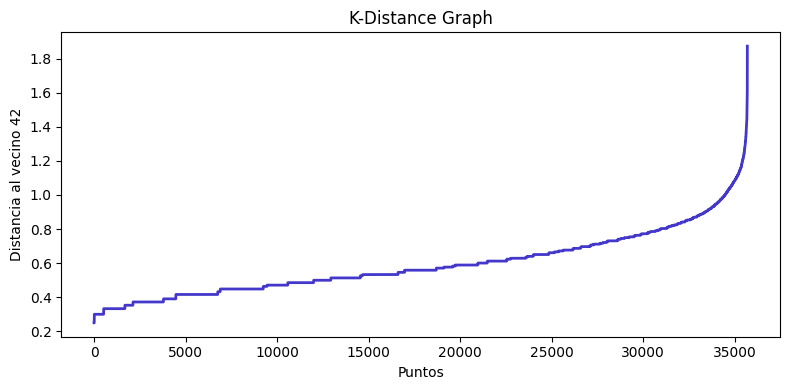

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

nearestN = NearestNeighbors(n_neighbors=42)
nearestN.fit(X_scaled)

distances, indices = nearestN.kneighbors(X_scaled)
distances_sorted = np.sort(distances[:,-1])[::1]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    distances_sorted,
    color='#4338CA',
    linewidth=2
)

ax.patch.set_alpha(0)
fig.patch.set_alpha(0)

plt.xlabel('Puntos')
plt.ylabel('Distancia al vecino 42')
plt.title('K-Distance Graph')

plt.tight_layout()
plt.show()

La gráfica de k-distancia muestra un codo alrededor de 0.6–0.7. Ese valor sugiere un eps adecuado para DBSCAN, porque separa las regiones densas de puntos de las áreas menos pobladas, y sirve como referencia para el siguiente experimento de clustering.

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

dbscan = DBSCAN(eps=0.6, min_samples=42)
labels_dbscan = dbscan.fit_predict(X_scaled)

print("Clusters encontrados:", np.unique(labels_dbscan))

Clusters encontrados: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13]


El primer ajuste de DBSCAN con eps=0.6 y min_samples=42 se ejecuta para observar cuántos clusters detecta y cuántos puntos clasifica como ruido. Esta fase exploratoria permite verificar si la configuración inicial genera agrupaciones estables o si es necesario aumentar min_samples.

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

dbscan = DBSCAN(eps=0.6, min_samples=418)
labels_dbscan = dbscan.fit_predict(X_scaled)

print("Clusters encontrados:", np.unique(labels_dbscan))

Clusters encontrados: [-1  0  1  2]


Análisis de resultados y discusión:

Se repite DBSCAN con eps=0.6 y min_samples=418 para obtener grupos más amplios y evitar ruido excesivo. La comparación con PCA permite evaluar si los clusters de densidad se alinean con la estructura real de severidad o si el dataset no tiene una separación clara en el espacio reducido.

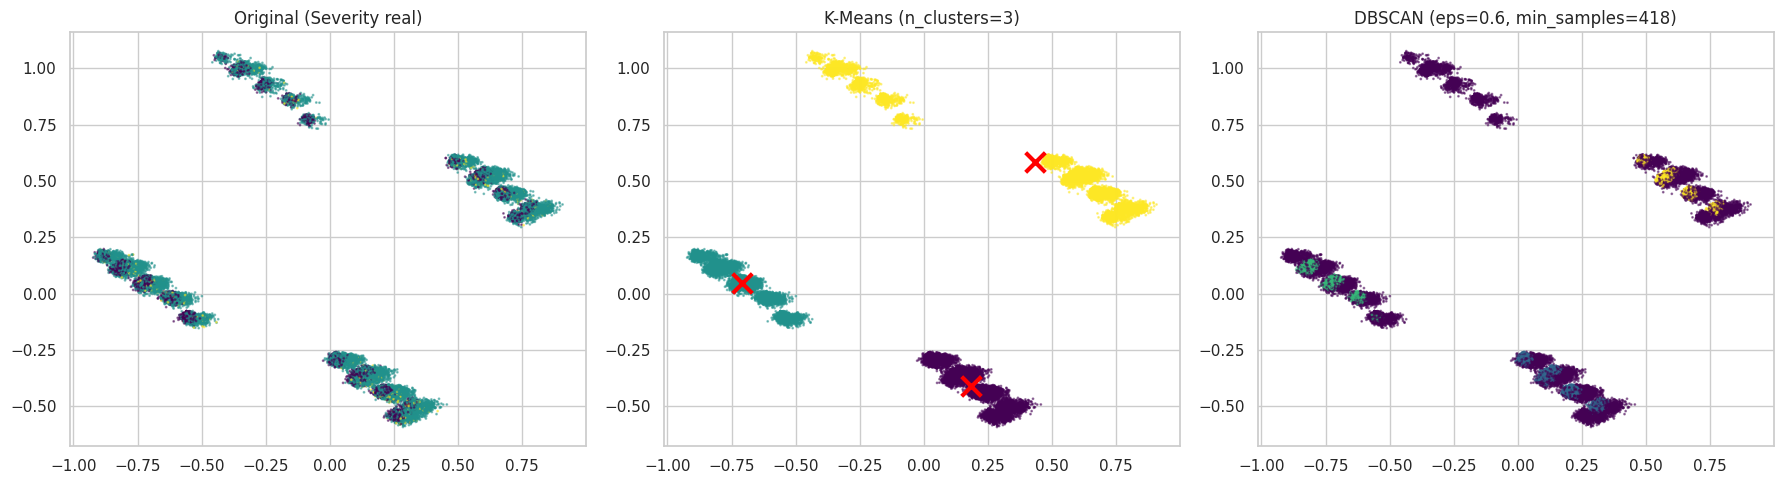

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=1,
alpha=0.5)
axes[0].set_title('Original (Severity real)')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans,
cmap='viridis', s=1, alpha=0.5)
axes[1].set_title('K-Means (n_clusters=3)')

axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbscan,
cmap='viridis', s=1, alpha=0.5)
axes[2].set_title('DBSCAN (eps=0.6, min_samples=418)')

# Centroides proyectados a PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)

# Dibujar centroides como X
axes[1].scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    marker='x',
    c='red',
    s=200,
    linewidths=3
)

fig.patch.set_alpha(0)


for ax in axes:
    ax.patch.set_alpha(0)

plt.tight_layout()
plt.show()

## Conclusiones

- El PCA solo logró capturar el 32% de la varianza, lo cual es una limitacion importante para la visualización, por esto para entrenar decidimos usar los datos solo con el scaler aplicado

- K-Means separó bien los 3 grupos geométricos, consistente con las 3 clases de Severity

- DBSCAN identificó clusters de alta densidad pero la mayoria de puntos quedó como ruido, sugiere que los datos no tienen estructura de densidad bien definida.

- Original vs clusters: los colores mezclados en el gráfico
  original confirman que en 2D las clases de Severity no son
  linealmente separables